# Patient Segmentation using K-Means and Hierarchical Clustering
* Yusuf Imantaka Bastari
* Muhammad Javier
* Khrisna Dwi Haryanto


## Data Cleaning

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('patient_segmentation_dataset.csv')
pd.set_option('display.max_columns', None)
df.dropna(inplace=True)

In [3]:
df.head()

,PatientID,Age,Gender,State,City,Height_cm,Weight_kg,BMI,Insurance_Type,Primary_Condition,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Last_Visit_Date,Days_Since_Last_Visit,Preventive_Care_Flag
0,P10000,64,Male,GA,Unknown,151,115,50.4,Private,Arthritis,3,7,2995.0,2025-07-18,186,0
1,P10001,59,Male,OH,Unknown,189,68,19.0,Medicare,Depression,1,8,1209.0,2025-12-12,39,0
2,P10002,58,Female,PA,Unknown,156,91,37.4,Private,Asthma,1,4,999.0,2025-09-16,126,0
3,P10003,43,Female,GA,Unknown,152,92,39.8,Medicare,Hypertension,1,6,5638.5,2025-04-09,286,1
4,P10004,53,Female,NC,Unknown,167,51,18.3,Medicaid,Asthma,1,4,5796.0,2025-03-07,319,0


In [4]:
df.dtypes

PatientID                     str
Age                         int64
Gender                        str
State                         str
City                          str
Height_cm                   int64
Weight_kg                   int64
BMI                       float64
Insurance_Type                str
Primary_Condition             str
Num_Chronic_Conditions      int64
Annual_Visits               int64
Avg_Billing_Amount        float64
Last_Visit_Date               str
Days_Since_Last_Visit       int64
Preventive_Care_Flag        int64
dtype: object

In [5]:
# Drop Unnecesary Columns

df_new = df.drop(columns=['PatientID'])

# Encode Categorical Variables

def encode_categorical(df):
    df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
    df['State'] = df['State'].map(df['State'].value_counts(normalize=True).to_dict())
    df['City'] = df['City'].map(df['City'].value_counts(normalize=True).to_dict())
    df['Insurance_Type'] = df['Insurance_Type'].map(df['Insurance_Type'].value_counts(normalize=True).to_dict())
    df['Primary_Condition'] = df['Primary_Condition'].map(df['Primary_Condition'].value_counts(normalize=True).to_dict())

    return df

encoded_df = encode_categorical(df_new)

In [6]:
encoded_df.head()

,Age,Gender,State,City,Height_cm,Weight_kg,BMI,Insurance_Type,Primary_Condition,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Last_Visit_Date,Days_Since_Last_Visit,Preventive_Care_Flag
0,64,0,0.106312,0.50299,151,115,50.4,0.257143,0.108306,3,7,2995.0,2025-07-18,186,0
1,59,0,0.100997,0.50299,189,68,19.0,0.534884,0.106312,1,8,1209.0,2025-12-12,39,0
2,58,1,0.097674,0.50299,156,91,37.4,0.257143,0.106312,1,4,999.0,2025-09-16,126,0
3,43,1,0.106312,0.50299,152,92,39.8,0.534884,0.139535,1,6,5638.5,2025-04-09,286,1
4,53,1,0.102326,0.50299,167,51,18.3,0.207973,0.106312,1,4,5796.0,2025-03-07,319,0


In [7]:
# Fix Date Time Column

encoded_df['Last_Visit_Date'] = pd.to_datetime(encoded_df['Last_Visit_Date'])

# Extract features from date time column

encoded_df['Last_Visit_Year'] = encoded_df['Last_Visit_Date'].dt.year
encoded_df['Last_Visit_Month'] = encoded_df['Last_Visit_Date'].dt.month
encoded_df['Last_Visit_Day'] = encoded_df['Last_Visit_Date'].dt.day

encoded_df = encoded_df.drop(columns=['Last_Visit_Date'])

In [8]:
encoded_df.isnull().sum()

Age                       0
Gender                    0
State                     0
City                      0
Height_cm                 0
Weight_kg                 0
BMI                       0
Insurance_Type            0
Primary_Condition         0
Num_Chronic_Conditions    0
Annual_Visits             0
Avg_Billing_Amount        0
Days_Since_Last_Visit     0
Preventive_Care_Flag      0
Last_Visit_Year           0
Last_Visit_Month          0
Last_Visit_Day            0
dtype: int64

# K-Means Clustering

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_df = scaler.fit_transform(encoded_df)

In [10]:
# Elbow method, find the optimal number of clusters

wcss = []

k_range = range(2, 45)

for k in k_range:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        max_iter=300,
        n_init=10,
        random_state=42
    )
    km.fit(scaled_df)
    wcss.append(km.inertia_)

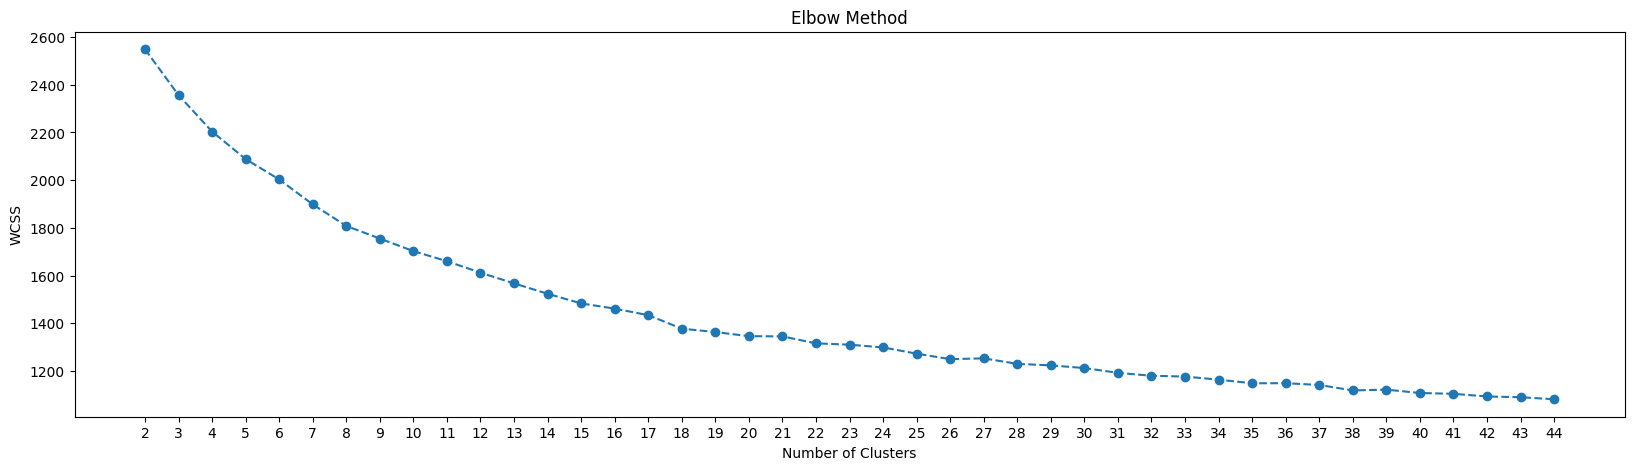

In [11]:
plt.figure(figsize=(20, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.xticks(k_range)
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

Best k by Silhouette: 18


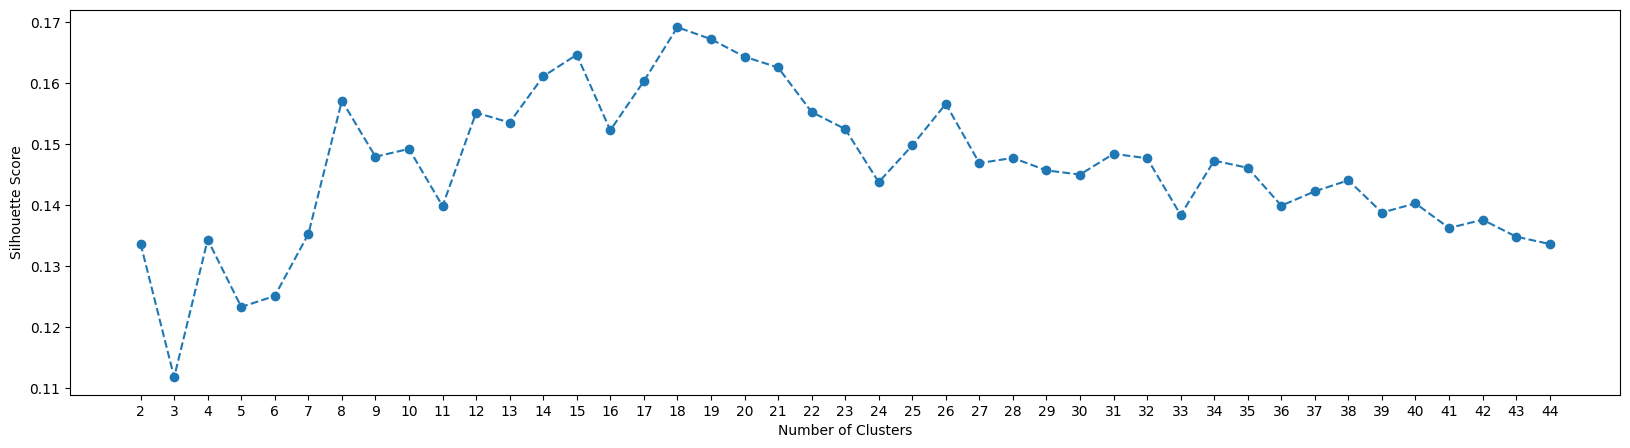

In [12]:
# Silhoutee scored

from sklearn.metrics import silhouette_score
import numpy as np

sil_scores = []

for k in k_range:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        max_iter=300,
        n_init=10,
        random_state=42
    )

    labels_tmp = km.fit_predict(scaled_df)
    sil_scores.append(silhouette_score(scaled_df, labels_tmp))

plt.figure(figsize=(20, 5))
plt.plot(k_range, sil_scores, marker='o', linestyle='--')
plt.xticks(k_range)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')

best_k = k_range[np.argmax(sil_scores)]
print(f"Best k by Silhouette: {best_k}")

In [13]:
kmeans = KMeans(
    n_clusters=best_k,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=42
)

kmeans.fit(scaled_df)

labels = kmeans.predict(scaled_df)

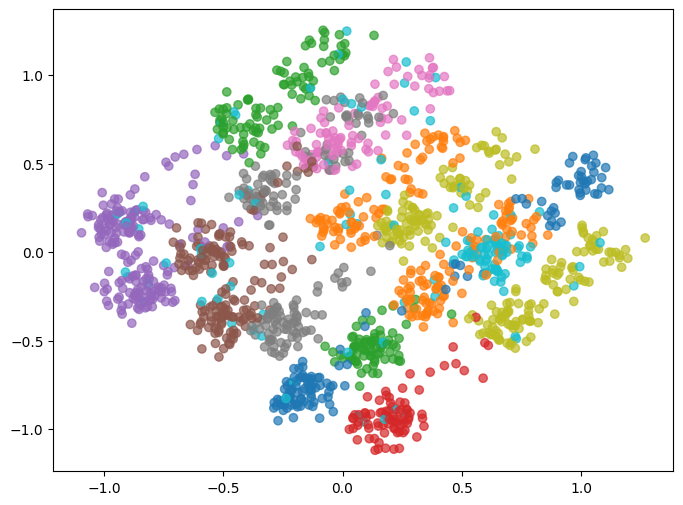

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_df)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=labels, cmap='tab10', alpha=0.7)

/tmp/ipykernel_94804/1471533899.py:16: UserWarning: Adding colorbar to a different Figure <Figure size 800x600 with 2 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(scatter, label='Cluster')


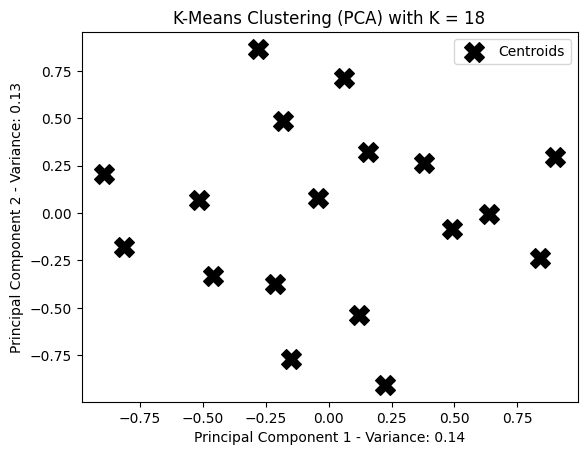

In [15]:
# Plot centroids in PCA space

centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=200,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title(f'K-Means Clustering (PCA) with K = {best_k}')
plt.xlabel(f'Principal Component 1 - Variance: {pca.explained_variance_ratio_[0]:.2f}')
plt.ylabel(f'Principal Component 2 - Variance: {pca.explained_variance_ratio_[1]:.2f}')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.show()

# Hierarchical (Agglomerative) Clustering

In [67]:
# Import library
from sklearn.cluster import AgglomerativeClustering

agg_clustering = AgglomerativeClustering(
    n_clusters=best_k,
    distance_threshold=None,
    metric='euclidean',
    linkage='ward',
    compute_full_tree='auto',
    compute_distances=False,
    memory=None,
    connectivity=None,
)

In [68]:
clusters_agg_labels = agg_clustering.fit_predict(scaled_df)

Best k by Silhouette: 19


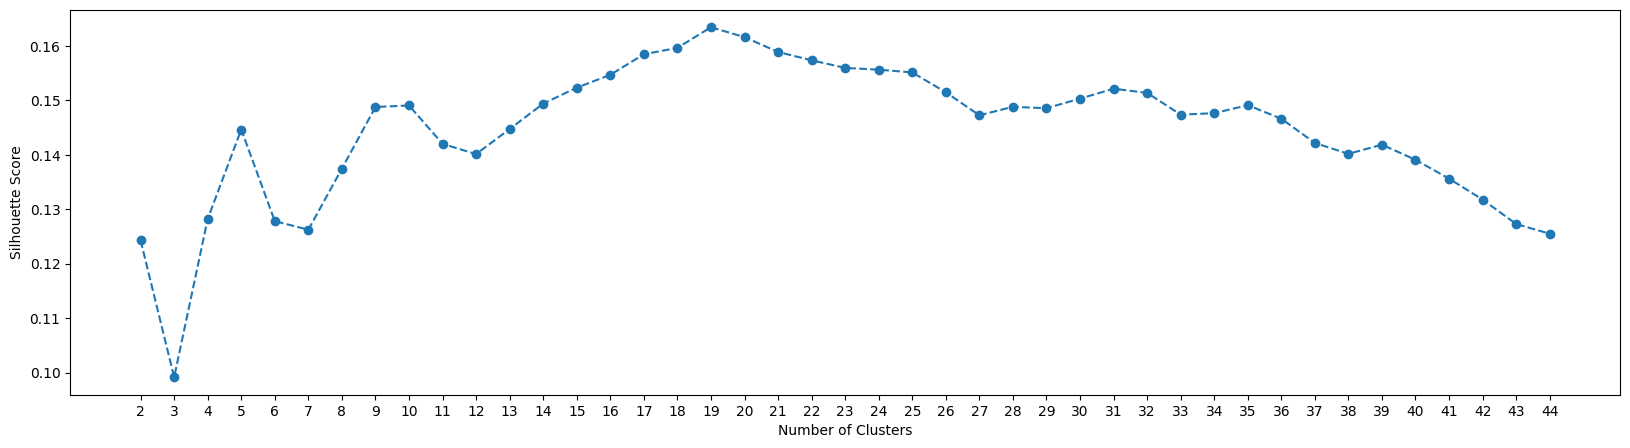

In [70]:
# Silhoutee scored

from sklearn.metrics import silhouette_score
import numpy as np

sil_scores = []

for k in k_range:
    agg_clustering = AgglomerativeClustering(
        n_clusters=k,
        distance_threshold=None,
        metric='euclidean',
        linkage='ward',
        compute_full_tree='auto',
        compute_distances=False,
        memory=None,
        connectivity=None,
    )

    cluster_agg_labels = agg_clustering.fit_predict(scaled_df)
    sil_scores.append(silhouette_score(scaled_df, cluster_agg_labels))

plt.figure(figsize=(20, 5))
plt.plot(k_range, sil_scores, marker='o', linestyle='--')
plt.xticks(k_range)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')

best_k = k_range[np.argmax(sil_scores)]
print(f"Best k by Silhouette: {best_k}")

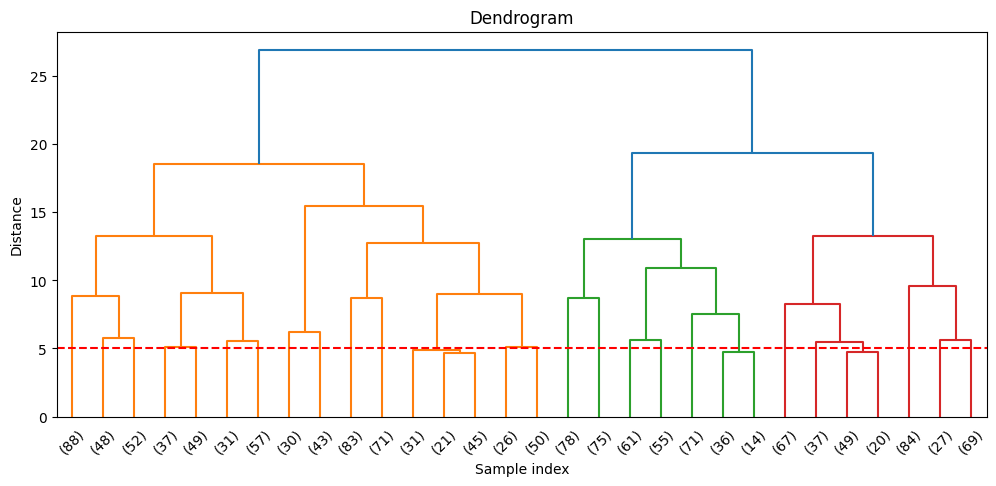

In [71]:
# Plotting dendogram
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(scaled_df, method='ward', metric='euclidean')

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=30)  
plt.title('Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.axhline(y=5, color='r', linestyle='--')  
plt.show()

# Low Silhouette Score Analysis

In [82]:
from sklearn.decomposition import PCA
import numpy as np

# Check how much variance 2 and 3 components capture
pca_check = PCA()
pca_check.fit(scaled_df)
cumvar = np.cumsum(pca_check.explained_variance_ratio_)


for i in range(len(cumvar)):
    print(f"{i+1} components: {cumvar[i]:.2%} variance")


1 components: 14.48% variance
2 components: 27.75% variance
3 components: 40.30% variance
4 components: 52.65% variance
5 components: 60.66% variance
6 components: 66.78% variance
7 components: 72.69% variance
8 components: 77.71% variance
9 components: 82.72% variance
10 components: 87.16% variance
11 components: 90.66% variance
12 components: 93.91% variance
13 components: 96.74% variance
14 components: 98.68% variance
15 components: 99.97% variance
16 components: 100.00% variance
17 components: 100.00% variance
